<a href="https://colab.research.google.com/github/rafaart/DataScienceCO/blob/develop/data_set_instagram.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## YURI OLIVEIRA DOS SANTOS e Rafael Santos Souza

# Projeto: Implementação e Análise do Algoritmo de Regressão Linear

# Sobre a base de dados🎲
Este conjunto de dados reúne informações sobre os principais influenciadores do Instagram, abrangendo uma variedade de 200 tipos diferentes de influenciadores. Ele inclui perfis com grande número de seguidores, alto engajamento e amplo alcance em suas postagens.


# Uso da base: 🛠️

O conjunto de dados pode ser usado para:

Esse tipo de conjunto de dados é usado para entender tendências nas mídias sociais, analisar o comportamento dos influenciadores e ajudar marcas a identificar os perfis mais adequados para campanhas de marketing.

# Objetivo do nosso projeto:🎯

Este notebook contempla a criação de um modelo preditivo usando o algoritmo de Regressão Linear para resolver um problema de inferência sobre taxa de engajamento dos principais influenciadores do instagram "Top Instagram Influencers Data" do Kaggle.

O link desta base e mais detalhes se encontra em: https://www.kaggle.com/datasets/surajjha101/top-instagram-influencers-data-cleaned

# <h1 style='background:#00FFFF; border:2; border-radius: 10px; font-size:250%; font-weight: bold; color:black'><center>TOP INSTAGRAM INFLUENCERS DATA</center></h1>

<img src = "https://i.gifer.com/9uhG.gif" width = 900 height = 400/>

Sobre este arquivo:

Neste arquivo, basicamente há 10 atributos. Ele foi ordenado com base na classificação que foi decidida com base em "seguidores".

rank: Classificação do Influenciador com base no número de seguidores que ele tem

channel_info: Nome de usuário do Instagrammer

influence score: Pontuação de influência dos usuários. É calculado com base em menções, importância e popularidade

posts: Número de posts que eles fizeram até agora

followers: Número de seguidores do usuário

avg_likes: Média de curtidas em posts do Instagrammer (total de curtidas/total de posts)

60_day_eng_rate: Taxa de engajamento dos últimos 60 dias do Instagrammer como facção de engajamentos que eles fizeram até agora

new_post_avg_like: Média de curtidas que eles têm em novos posts

total de curtidas: Total de curtidas que o usuário obteve em seus posts. (em bilhões)

country: País ou região de origem do usuário.
<a id='top'></a>
<div class="list-group" id="list-tab" role="tablist">
    

# Importando as bibliotecas 📚

In [ ]:
#importando as bibliotecas
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import linear_model
from sklearn.metrics import mean_squared_error
from sklearn import tree
from sklearn.linear_model import LinearRegression  # Modelo de Regressão Linear
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  # Métricas de avaliação do modelo
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [ ]:
!gdown 1MYTK4jR7XnzSJvqFVI5-sl3FLOgqqanC

Failed to retrieve file url:

	Cannot retrieve the public link of the file. You may need to change
	the permission to 'Anyone with the link', or have had many accesses.
	Check FAQ in https://github.com/wkentaro/gdown?tab=readme-ov-file#faq.

You may still be able to access the file from the browser:

	https://drive.google.com/uc?id=1MYTK4jR7XnzSJvqFVI5-sl3FLOgqqanC

but Gdown can't. Please check connections and permissions.


In [ ]:
#https://drive.google.com/file/d/1MYTK4jR7XnzSJvqFVI5-sl3FLOgqqanC/view?usp=drive_link

# Carregando o Data frame 📤

In [ ]:
dataset = pd.read_csv('/content/drive/MyDrive/dados_inst/archive (2).zip')
dataset.head()

,rank,channel_info,influence_score,posts,followers,avg_likes,60_day_eng_rate,new_post_avg_like,total_likes,country
0,1,cristiano,92,3.3k,475.8m,8.7m,1.39%,6.5m,29.0b,Spain
1,2,kyliejenner,91,6.9k,366.2m,8.3m,1.62%,5.9m,57.4b,United States
2,3,leomessi,90,0.89k,357.3m,6.8m,1.24%,4.4m,6.0b,NaN
3,4,selenagomez,93,1.8k,342.7m,6.2m,0.97%,3.3m,11.5b,United States
4,5,therock,91,6.8k,334.1m,1.9m,0.20%,665.3k,12.5b,United States


In [ ]:
#Vamos renomear as colunas para facilitar a interpretação
dataset.rename(columns={'rank':'Classificação'}, inplace=True)
dataset.rename(columns={'channel_info': 'Nome'}, inplace=True)
dataset.rename(columns={'influence_score': 'Pontuação'}, inplace=True)
dataset.rename(columns={'posts': 'Postagens'}, inplace=True)
dataset.rename(columns={'followers': 'Seguidores'}, inplace=True)
dataset.rename(columns={'avg_likes': 'Media_Curtidas(target)'}, inplace=True)
dataset.rename(columns={'60_day_eng_rate': 'Taxa_Engajamento'}, inplace=True)
dataset.rename(columns={'new_post_avg_like': 'Media_Curtidas_Novas'}, inplace=True)
dataset.rename(columns={'total_likes': 'Likes'}, inplace=True)
dataset.rename(columns={'country': 'País'}, inplace=True)

In [ ]:
#visualizando o data set
dataset

,Classificação,Nome,Pontuação,Postagens,Seguidores,Media_Curtidas(target),Taxa_Engajamento,Media_Curtidas_Novas,Likes,País
0,1,cristiano,92,3.3k,475.8m,8.7m,1.39%,6.5m,29.0b,Spain
1,2,kyliejenner,91,6.9k,366.2m,8.3m,1.62%,5.9m,57.4b,United States
2,3,leomessi,90,0.89k,357.3m,6.8m,1.24%,4.4m,6.0b,NaN
3,4,selenagomez,93,1.8k,342.7m,6.2m,0.97%,3.3m,11.5b,United States
4,5,therock,91,6.8k,334.1m,1.9m,0.20%,665.3k,12.5b,United States
...,...,...,...,...,...,...,...,...,...,...
195,196,iambeckyg,71,2.3k,33.2m,623.8k,1.40%,464.7k,1.4b,United States
196,197,nancyajram,81,3.8k,33.2m,390.4k,0.64%,208.0k,1.5b,France
197,198,luansantana,79,0.77k,33.2m,193.3k,0.26%,82.6k,149.2m,Brazil
198,199,nickjonas,78,2.3k,33.0m,719.6k,1.42%,467.7k,1.7b,United States


# Análise Inicial dos Dados 🔍

In [ ]:
# 1. Exibir as primeiras 10 linhas do DataFrame
dataset.head(10)

,Classificação,Nome,Pontuação,Postagens,Seguidores,Media_Curtidas(target),Taxa_Engajamento,Media_Curtidas_Novas,Likes,País
0,1,cristiano,92,3.3k,475.8m,8.7m,1.39%,6.5m,29.0b,Spain
1,2,kyliejenner,91,6.9k,366.2m,8.3m,1.62%,5.9m,57.4b,United States
2,3,leomessi,90,0.89k,357.3m,6.8m,1.24%,4.4m,6.0b,NaN
3,4,selenagomez,93,1.8k,342.7m,6.2m,0.97%,3.3m,11.5b,United States
4,5,therock,91,6.8k,334.1m,1.9m,0.20%,665.3k,12.5b,United States
5,6,kimkardashian,91,5.6k,329.2m,3.5m,0.88%,2.9m,19.9b,United States
6,7,arianagrande,92,5.0k,327.7m,3.7m,1.20%,3.9m,18.4b,United States
7,8,beyonce,92,2.0k,272.8m,3.6m,0.76%,2.0m,7.4b,United States
8,9,khloekardashian,89,4.1k,268.3m,2.4m,0.35%,926.9k,9.8b,United States
9,10,justinbieber,91,7.4k,254.5m,1.9m,0.59%,1.5m,13.9b,Canada


In [ ]:
# 2. Obter um resumo das estatísticas descritivas das colunas numéricas
dataset.describe()

,Classificação,Pontuação
count,200.000000,200.000000
mean,100.500000,81.820000
std,57.879185,8.878159
min,1.000000,22.000000
25%,50.750000,80.000000
50%,100.500000,84.000000
75%,150.250000,86.000000
max,200.000000,93.000000


In [ ]:
# 3. Verificar se há valores ausentes em alguma coluna
dataset.isna().sum()

,0
Classificação,0
Nome,0
Pontuação,0
Postagens,0
Seguidores,0
Media_Curtidas(target),0
Taxa_Engajamento,0
Media_Curtidas_Novas,0
Likes,0
País,62


In [ ]:
#4.visualização dos nomes das colunas
dataset.columns

Index(['Classificação', 'Nome', 'Pontuação', 'Postagens', 'Seguidores',
       'Media_Curtidas(target)', 'Taxa_Engajamento', 'Media_Curtidas_Novas',
       'Likes', 'País'],
      dtype='object')

In [ ]:
dataset['Nome'].value_counts()

,count
Nome,
cristiano,1
kapilsharma,1
maisa,1
luissuarez9,1
gusttavolima,1
...,...
roses_are_rosie,1
manchesterunited,1
anushkasharma,1


# Feature Engineering 🛠️

Neste próximo passo, serão feitas transformações nas variáveis ​​do conjunto de dados para entender como a variável alvo varia em resposta às mudanças nas variáveis ​​preditoras.

In [ ]:
df_insta = pd.DataFrame()

# Aplicar a função à coluna "Seguidores"
df_insta['Influenciador'] = dataset['Nome']
df_insta['Classificação'] = dataset['Classificação']

def convert_postagens(value):
    if isinstance(value, str):  # Verifica se o valor é uma string
        if 'm' in value:
            return float(value.replace('m', '')) * 1000000
        elif 'k' in value:
            return float(value.replace('k', '')) * 1000
        elif 'b' in value:
            return float(value.replace('b', '')) * 1000000000
        else:
            return float(value)  # Caso não tenha 'm', 'k' ou 'b'
    else:
        return value  # Se já for numérico, retorna o valor como está

# Aplicar a função de conversão para colunas relevantes
df_insta['Postagens'] = dataset['Postagens'].apply(convert_postagens)
df_insta['Seguidores'] = dataset['Seguidores'].apply(convert_postagens)
df_insta['Media_Curtidas(target)'] = dataset['Media_Curtidas(target)'].apply(convert_postagens)
df_insta['Media_Curtidas_Novas'] = dataset['Media_Curtidas_Novas'].apply(convert_postagens)

# Converter a taxa de engajamento para um número decimal
df_insta["Taxa_Engajamento"] = dataset["Taxa_Engajamento"].str.replace("%", "", regex=True).astype(float) / 100

# Adicionar a coluna de País
df_insta['País'] = dataset['País']

# Visualizar o DataFrame final
print(df_insta.head())  # Mostrar as primeiras linhas do novo DataFrame após o pré-processamento


  Influenciador  Classificação  Postagens   Seguidores  \
0     cristiano              1     3300.0  475800000.0   
1   kyliejenner              2     6900.0  366200000.0   
2      leomessi              3      890.0  357300000.0   
3   selenagomez              4     1800.0  342700000.0   
4       therock              5     6800.0  334100000.0   

   Media_Curtidas(target)  Media_Curtidas_Novas  Taxa_Engajamento  \
0               8700000.0             6500000.0            0.0139   
1               8300000.0             5900000.0            0.0162   
2               6800000.0             4400000.0            0.0124   
3               6200000.0             3300000.0            0.0097   
4               1900000.0              665300.0            0.0020   

            País  
0          Spain  
1  United States  
2            NaN  
3  United States  
4  United States  


# Utilizando a nova base de dados (df_insta) 👾

In [ ]:
df_insta.head(10)

,Influenciador,Classificação,Postagens,Seguidores,Media_Curtidas(target),Media_Curtidas_Novas,Taxa_Engajamento,País
0,cristiano,1,3300.0,475800000.0,8700000.0,6500000.0,0.0139,Spain
1,kyliejenner,2,6900.0,366200000.0,8300000.0,5900000.0,0.0162,United States
2,leomessi,3,890.0,357300000.0,6800000.0,4400000.0,0.0124,NaN
3,selenagomez,4,1800.0,342700000.0,6200000.0,3300000.0,0.0097,United States
4,therock,5,6800.0,334100000.0,1900000.0,665300.0,0.0020,United States
5,kimkardashian,6,5600.0,329200000.0,3500000.0,2900000.0,0.0088,United States
6,arianagrande,7,5000.0,327700000.0,3700000.0,3900000.0,0.0120,United States
7,beyonce,8,2000.0,272800000.0,3600000.0,2000000.0,0.0076,United States
8,khloekardashian,9,4100.0,268300000.0,2400000.0,926900.0,0.0035,United States
9,justinbieber,10,7400.0,254500000.0,1900000.0,1500000.0,0.0059,Canada


In [ ]:
#Verificando informações da base de dados
df_insta.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Influenciador           200 non-null    object 
 1   Classificação           200 non-null    int64  
 2   Postagens               200 non-null    float64
 3   Seguidores              200 non-null    float64
 4   Media_Curtidas(target)  200 non-null    float64
 5   Media_Curtidas_Novas    200 non-null    float64
 6   Taxa_Engajamento        199 non-null    float64
 7   País                    138 non-null    object 
dtypes: float64(5), int64(1), object(2)
memory usage: 12.6+ KB


In [ ]:
# obter um resumo conciso e informativo sobre um conjunto de dados
df_insta.describe()


,Classificação,Postagens,Seguidores,Media_Curtidas(target),Media_Curtidas_Novas,Taxa_Engajamento
count,200.000000,200.000000,2.000000e+02,2.000000e+02,2.000000e+02,199.000000
mean,100.500000,3499.850000,7.740950e+07,1.787104e+06,1.208132e+06,0.019020
std,57.879185,3475.828158,7.368727e+07,2.193359e+06,1.858322e+06,0.033297
min,1.000000,10.000000,3.280000e+07,6.510000e+04,0.000000e+00,0.000100
25%,50.750000,947.500000,4.000000e+07,5.044000e+05,1.957500e+05,0.004100
50%,100.500000,2100.000000,5.005000e+07,1.100000e+06,5.321500e+05,0.008800
75%,150.250000,5025.000000,6.890000e+07,2.100000e+06,1.325000e+06,0.020350
max,200.000000,17500.000000,4.758000e+08,1.540000e+07,1.260000e+07,0.264100


In [ ]:
#identificar o valores nulos no date frame
df_insta.isnull().sum()

,0
Influenciador,0
Classificação,0
Postagens,0
Seguidores,0
Media_Curtidas(target),0
Media_Curtidas_Novas,0
Taxa_Engajamento,1
País,62


In [ ]:
#limpar os Nan
df_insta.dropna(inplace=True)

In [ ]:
#verificando os 10 itens primeiros do data frame (df_insta)
df_insta.head(10)

,Influenciador,Classificação,Postagens,Seguidores,Media_Curtidas(target),Media_Curtidas_Novas,Taxa_Engajamento,País
0,cristiano,1,3300.0,475800000.0,8700000.0,6500000.0,0.0139,Spain
1,kyliejenner,2,6900.0,366200000.0,8300000.0,5900000.0,0.0162,United States
3,selenagomez,4,1800.0,342700000.0,6200000.0,3300000.0,0.0097,United States
4,therock,5,6800.0,334100000.0,1900000.0,665300.0,0.0020,United States
5,kimkardashian,6,5600.0,329200000.0,3500000.0,2900000.0,0.0088,United States
6,arianagrande,7,5000.0,327700000.0,3700000.0,3900000.0,0.0120,United States
7,beyonce,8,2000.0,272800000.0,3600000.0,2000000.0,0.0076,United States
8,khloekardashian,9,4100.0,268300000.0,2400000.0,926900.0,0.0035,United States
9,justinbieber,10,7400.0,254500000.0,1900000.0,1500000.0,0.0059,Canada
10,kendalljenner,11,660.0,254000000.0,5500000.0,5100000.0,0.0204,United States


In [ ]:
#verificando os 10 ultimos itens do dataframe (df_insta)
df_insta.tail(10)

,Influenciador,Classificação,Postagens,Seguidores,Media_Curtidas(target),Media_Curtidas_Novas,Taxa_Engajamento,País
190,bmw,191,9300.0,33700000.0,231300.0,76500.0,0.0023,Germany
191,danbilzerian,192,1400.0,33600000.0,2000000.0,1200000.0,0.0358,Canada
192,khabib_nurmagomedov,193,4500.0,33500000.0,685100.0,220700.0,0.0067,Russia
193,zidane,194,370.0,33500000.0,1100000.0,532700.0,0.0161,France
194,sonamkapoor,195,4800.0,33300000.0,264700.0,209200.0,0.0063,India
195,iambeckyg,196,2300.0,33200000.0,623800.0,464700.0,0.0140,United States
196,nancyajram,197,3800.0,33200000.0,390400.0,208000.0,0.0064,France
197,luansantana,198,770.0,33200000.0,193300.0,82600.0,0.0026,Brazil
198,nickjonas,199,2300.0,33000000.0,719600.0,467700.0,0.0142,United States
199,raisa6690,200,4200.0,32800000.0,232200.0,97400.0,0.0030,Indonesia


# Tratando os dados categóricos 🅰️

LabelEncoder é uma técnica de pré-processamento de dados que transforma valores categóricos em valores numéricos. Ele atribui um número único a cada categoria, criando uma correspondência entre a categoria original e um número inteiro.

In [ ]:
#transformar variaveis categóricas em númericas
label_encoders = {}
for column in ['Influenciador', 'País']:
    le = LabelEncoder()
    df_insta[column] = le.fit_transform(df_insta[column])
    label_encoders[column] = le

# Analisando as variáveis que vão compor nosso modelo 📊

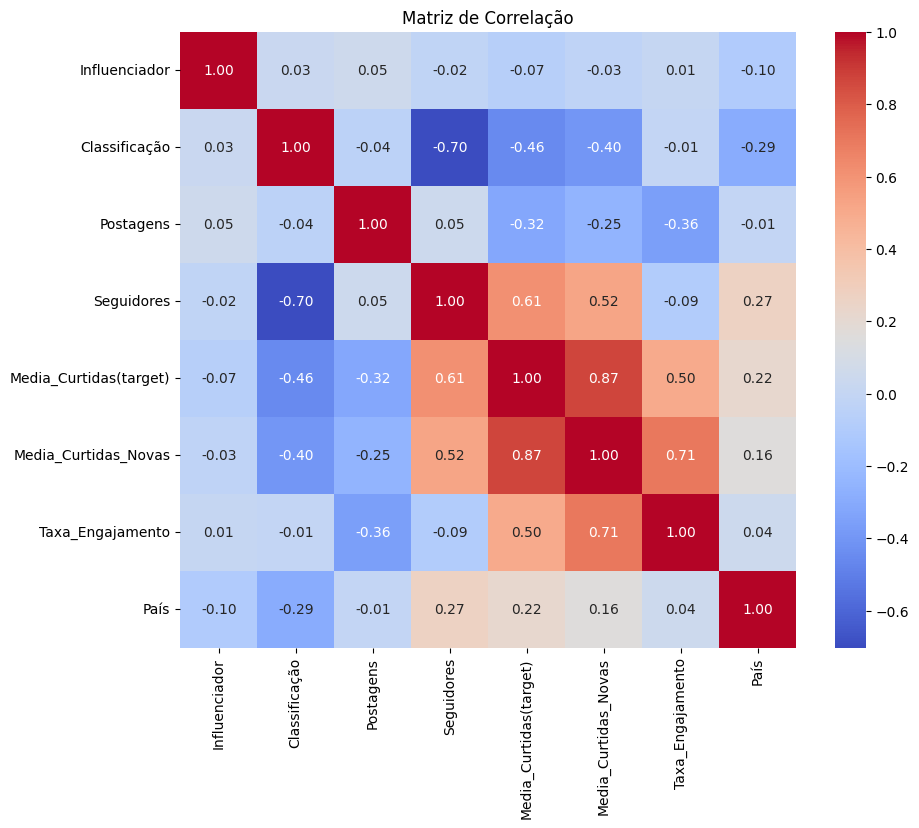

In [ ]:
#visualizando correlação
matriz_correlacao =  df_insta.select_dtypes(include=[np.number]).corr()
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_correlacao, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title('Matriz de Correlação')
plt.show()

In [ ]:
#verificando as correlações das variaveis
correlation_matrix = df_insta.corr()
print("\nMatriz de correlação:")
print(correlation_matrix)


Matriz de correlação:
                        Influenciador  Classificação  Postagens  Seguidores  \
Influenciador                1.000000       0.026635   0.052931   -0.019446   
Classificação                0.026635       1.000000  -0.038108   -0.702439   
Postagens                    0.052931      -0.038108   1.000000    0.047782   
Seguidores                  -0.019446      -0.702439   0.047782    1.000000   
Media_Curtidas(target)      -0.065927      -0.455890  -0.319911    0.610347   
Media_Curtidas_Novas        -0.028332      -0.402640  -0.253575    0.523557   
Taxa_Engajamento             0.005765      -0.007923  -0.357878   -0.093967   
País                        -0.103806      -0.292562  -0.007366    0.265539   

                        Media_Curtidas(target)  Media_Curtidas_Novas  \
Influenciador                        -0.065927             -0.028332   
Classificação                        -0.455890             -0.402640   
Postagens                            -0.319911   

In [ ]:
#Verificar o grau da variavel de correlação
important_columns = correlation_matrix['Media_Curtidas(target)'].sort_values(ascending=False)
print("\nColunas mais importantes com base na correlação:")
print(important_columns)


Colunas mais importantes com base na correlação:
Media_Curtidas(target)    1.000000
Media_Curtidas_Novas      0.871394
Seguidores                0.610347
Taxa_Engajamento          0.495045
País                      0.218628
Influenciador            -0.065927
Postagens                -0.319911
Classificação            -0.455890
Name: Media_Curtidas(target), dtype: float64


In [ ]:
# vamo verificar a multicolinearidade com o VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

# vamo excluir as colunas não numéricas e a variável alvo:
variaveis_independentes = df_insta.drop (columns = ['Media_Curtidas(target)'])

variaveis_independentes = sm.add_constant (variaveis_independentes)  #-> add uma constante pra interceptação
vif = pd.DataFrame()
vif ["Variável"] = variaveis_independentes.columns
vif ["VIF"] = [variance_inflation_factor (variaveis_independentes.values, i) for i in range (variaveis_independentes.shape [1])]
print (vif)

               Variável        VIF
0                 const  26.998961
1         Influenciador   1.018802
2         Classificação   2.054521
3             Postagens   1.154224
4            Seguidores   4.734357
5  Media_Curtidas_Novas   6.818264
6      Taxa_Engajamento   5.167428
7                  País   1.123366


In [ ]:
from sklearn.preprocessing import StandardScaler

# Selecionando as variáveis independentes (todas as variáveis preditoras)
X = df_insta[['Media_Curtidas_Novas', 'Seguidores', 'Taxa_Engajamento', 'País', 'Influenciador', 'Postagens', 'Classificação']]

# Normalizando os dados
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)




In [ ]:
from sklearn.decomposition import PCA

# Criando o modelo PCA
pca = PCA()

# Ajustando o PCA nos dados normalizados
X_pca = pca.fit_transform(X_scaled)


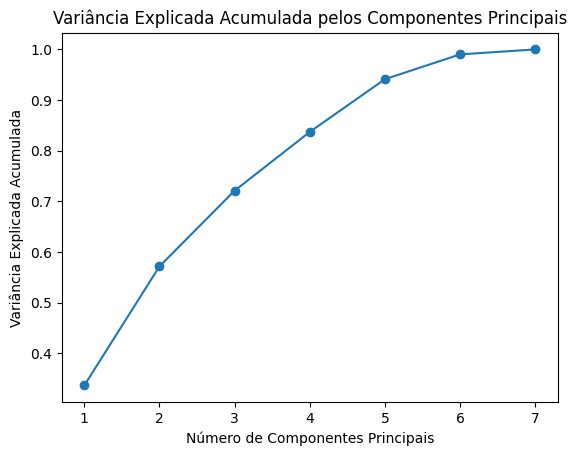

In [ ]:
# Verificando a variância explicada por cada componente principal
explained_variance = pca.explained_variance_ratio_

# Visualizando a variância explicada acumulada
import matplotlib.pyplot as plt

plt.plot(range(1, len(explained_variance)+1), explained_variance.cumsum(), marker='o')
plt.title('Variância Explicada Acumulada pelos Componentes Principais')
plt.xlabel('Número de Componentes Principais')
plt.ylabel('Variância Explicada Acumulada')
plt.show()


In [ ]:
# Exibindo os coeficientes dos componentes principais (loadings)
print("Coeficientes dos componentes principais (loadings):")
print(pca.components_)


Coeficientes dos componentes principais (loadings):
[[ 0.56174645  0.49551259  0.31213343  0.28275127 -0.05485544 -0.1599898
  -0.48262489]
 [ 0.27273373 -0.38016525  0.60740446 -0.20724357  0.0129035  -0.48974021
   0.35942821]
 [ 0.11978051  0.11697218  0.05717064 -0.37572439  0.89002406  0.16975772
  -0.08106996]
 [-0.14829104 -0.21246392  0.05626262  0.84635174  0.43250855 -0.10203999
   0.12615983]
 [ 0.24110323 -0.17827229  0.39881946  0.1142932  -0.13072654  0.833642
   0.16099665]
 [ 0.29142027  0.51864811 -0.24235663  0.07591012  0.01218553 -0.01316216
   0.76240249]
 [ 0.65624927 -0.50034126 -0.55624175  0.02822162  0.01949369 -0.01399006
  -0.09065573]]


In [ ]:
# Selecionando o número de componentes para manter (exemplo: 2 componentes)
pca = PCA(n_components=7)
X_pca = pca.fit_transform(X_scaled)

# Visualizando os novos componentes principais
print(X_pca[:7])  # Primeiras 5 observações nos novos componentes


[[ 5.67176451 -1.19114697  0.20339492 -2.19940465 -0.12066442  2.5090861
   0.44195813]
 [ 4.7702098  -1.35137115  0.80021344 -0.85464244  0.85661703  1.71029713
   0.77617948]
 [ 3.5529738  -1.27452332  1.2691832   0.11816353 -1.04455361  1.1298515
  -0.13371995]
 [ 1.99560997 -2.71721741  1.45190104  0.3813912  -0.54356774  0.59294407
  -1.17110518]
 [ 3.16479959 -1.84890483  0.29335531 -0.44032436 -0.05544029  0.96343215
  -0.2634529 ]
 [ 3.73407693 -1.45588528 -0.88860941 -1.12774186  0.24888922  1.12981371
   0.11845537]
 [ 2.6273518  -1.32132765 -1.16494046 -0.63009441 -0.79278656  0.44172907
  -0.33885057]]


In [ ]:
# Criando um novo DataFrame com os componentes principais
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2','PC3','PC4','PC5','PC6','PC7'])

# Agora, use df_pca como entradas no modelo de regressão


In [ ]:
from sklearn.linear_model import LinearRegression

# Definindo as variáveis independentes e a variável alvo
X_pca_df = df_pca[['PC1', 'PC2','PC3','PC4','PC5','PC6','PC7']]  # Exemplo com 2 componentes principais
y = df_insta['Media_Curtidas(target)']  # Supondo que 'target' seja a variável alvo (curtidas, por exemplo)

# Ajustando o modelo de regressão linear
model = LinearRegression()
model.fit(X_pca_df, y)

# Fazendo previsões
y_pred = model.predict(X_pca_df)


In [ ]:
from sklearn.metrics import r2_score

# Prevendo com o modelo
y_pred = model.predict(X_pca_df)

# Calculando R²
r2 = r2_score(y, y_pred)
print(f'R²: {r2}')


R²: 0.8212529882418667


In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Calculando o erro quadrático médio (MSE)
mse = mean_squared_error(y, y_pred)

# Calculando RMSE
rmse = np.sqrt(mse)
print(f'RMSE: {rmse}')

RMSE: 647530.9064612229


In [ ]:
from sklearn.metrics import mean_absolute_error

# Calculando MAE
mae = mean_absolute_error(y, y_pred)
print(f'MAE: {mae}')


MAE: 438212.395508295


In [ ]:
# Calculando o erro absoluto médio percentual
mape = np.mean(np.abs((y - y_pred) / y)) * 100
print(f'MAPE: {mape}%')


MAPE: 61.039877313752065%


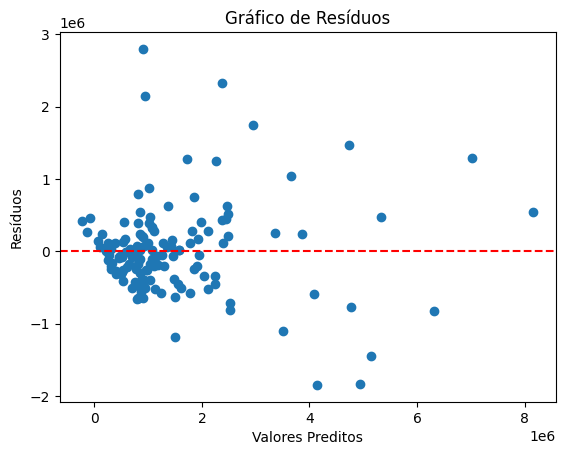

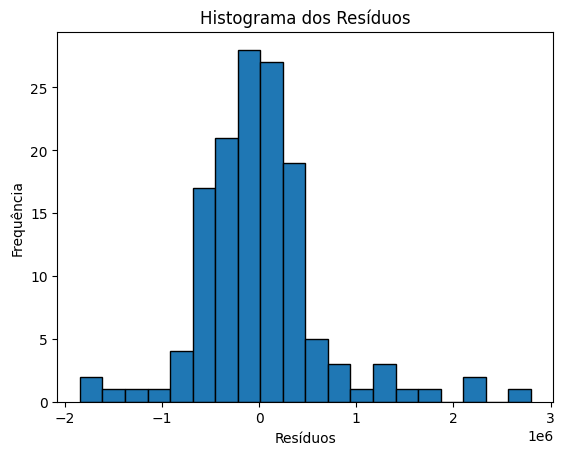

In [ ]:
import matplotlib.pyplot as plt

# Plotando os resíduos
residuals = y - y_pred

# Gráfico de dispersão dos resíduos
plt.scatter(y_pred, residuals)
plt.axhline(0, color='r', linestyle='--')
plt.title('Gráfico de Resíduos')
plt.xlabel('Valores Preditos')
plt.ylabel('Resíduos')
plt.show()

# Histograma dos resíduos
plt.hist(residuals, bins=20, edgecolor='black')
plt.title('Histograma dos Resíduos')
plt.xlabel('Resíduos')
plt.ylabel('Frequência')
plt.show()


In [ ]:
from sklearn.model_selection import cross_val_score

# Realizando a validação cruzada
cv_scores = cross_val_score(model, X_pca_df, y, cv=5, scoring='neg_mean_squared_error')

# Exibindo as pontuações da validação cruzada
print(f'CV RMSE: {np.sqrt(-cv_scores)}')


CV RMSE: [1499675.3754463   525756.81311304  972531.72143197  473059.91892849
  551431.12360441]


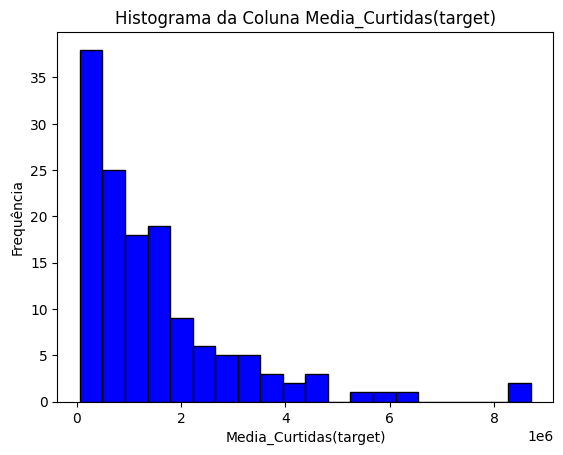

In [ ]:
# Analisando a coluna "Media_Curtidas(target)" para criar a nossa target
import matplotlib.pyplot as plt
plt.hist(df_insta['Media_Curtidas(target)'], bins=20, color='blue', edgecolor='black')
plt.xlabel('Media_Curtidas(target)')
plt.ylabel('Frequência')
plt.title('Histograma da Coluna Media_Curtidas(target)')
plt.show()

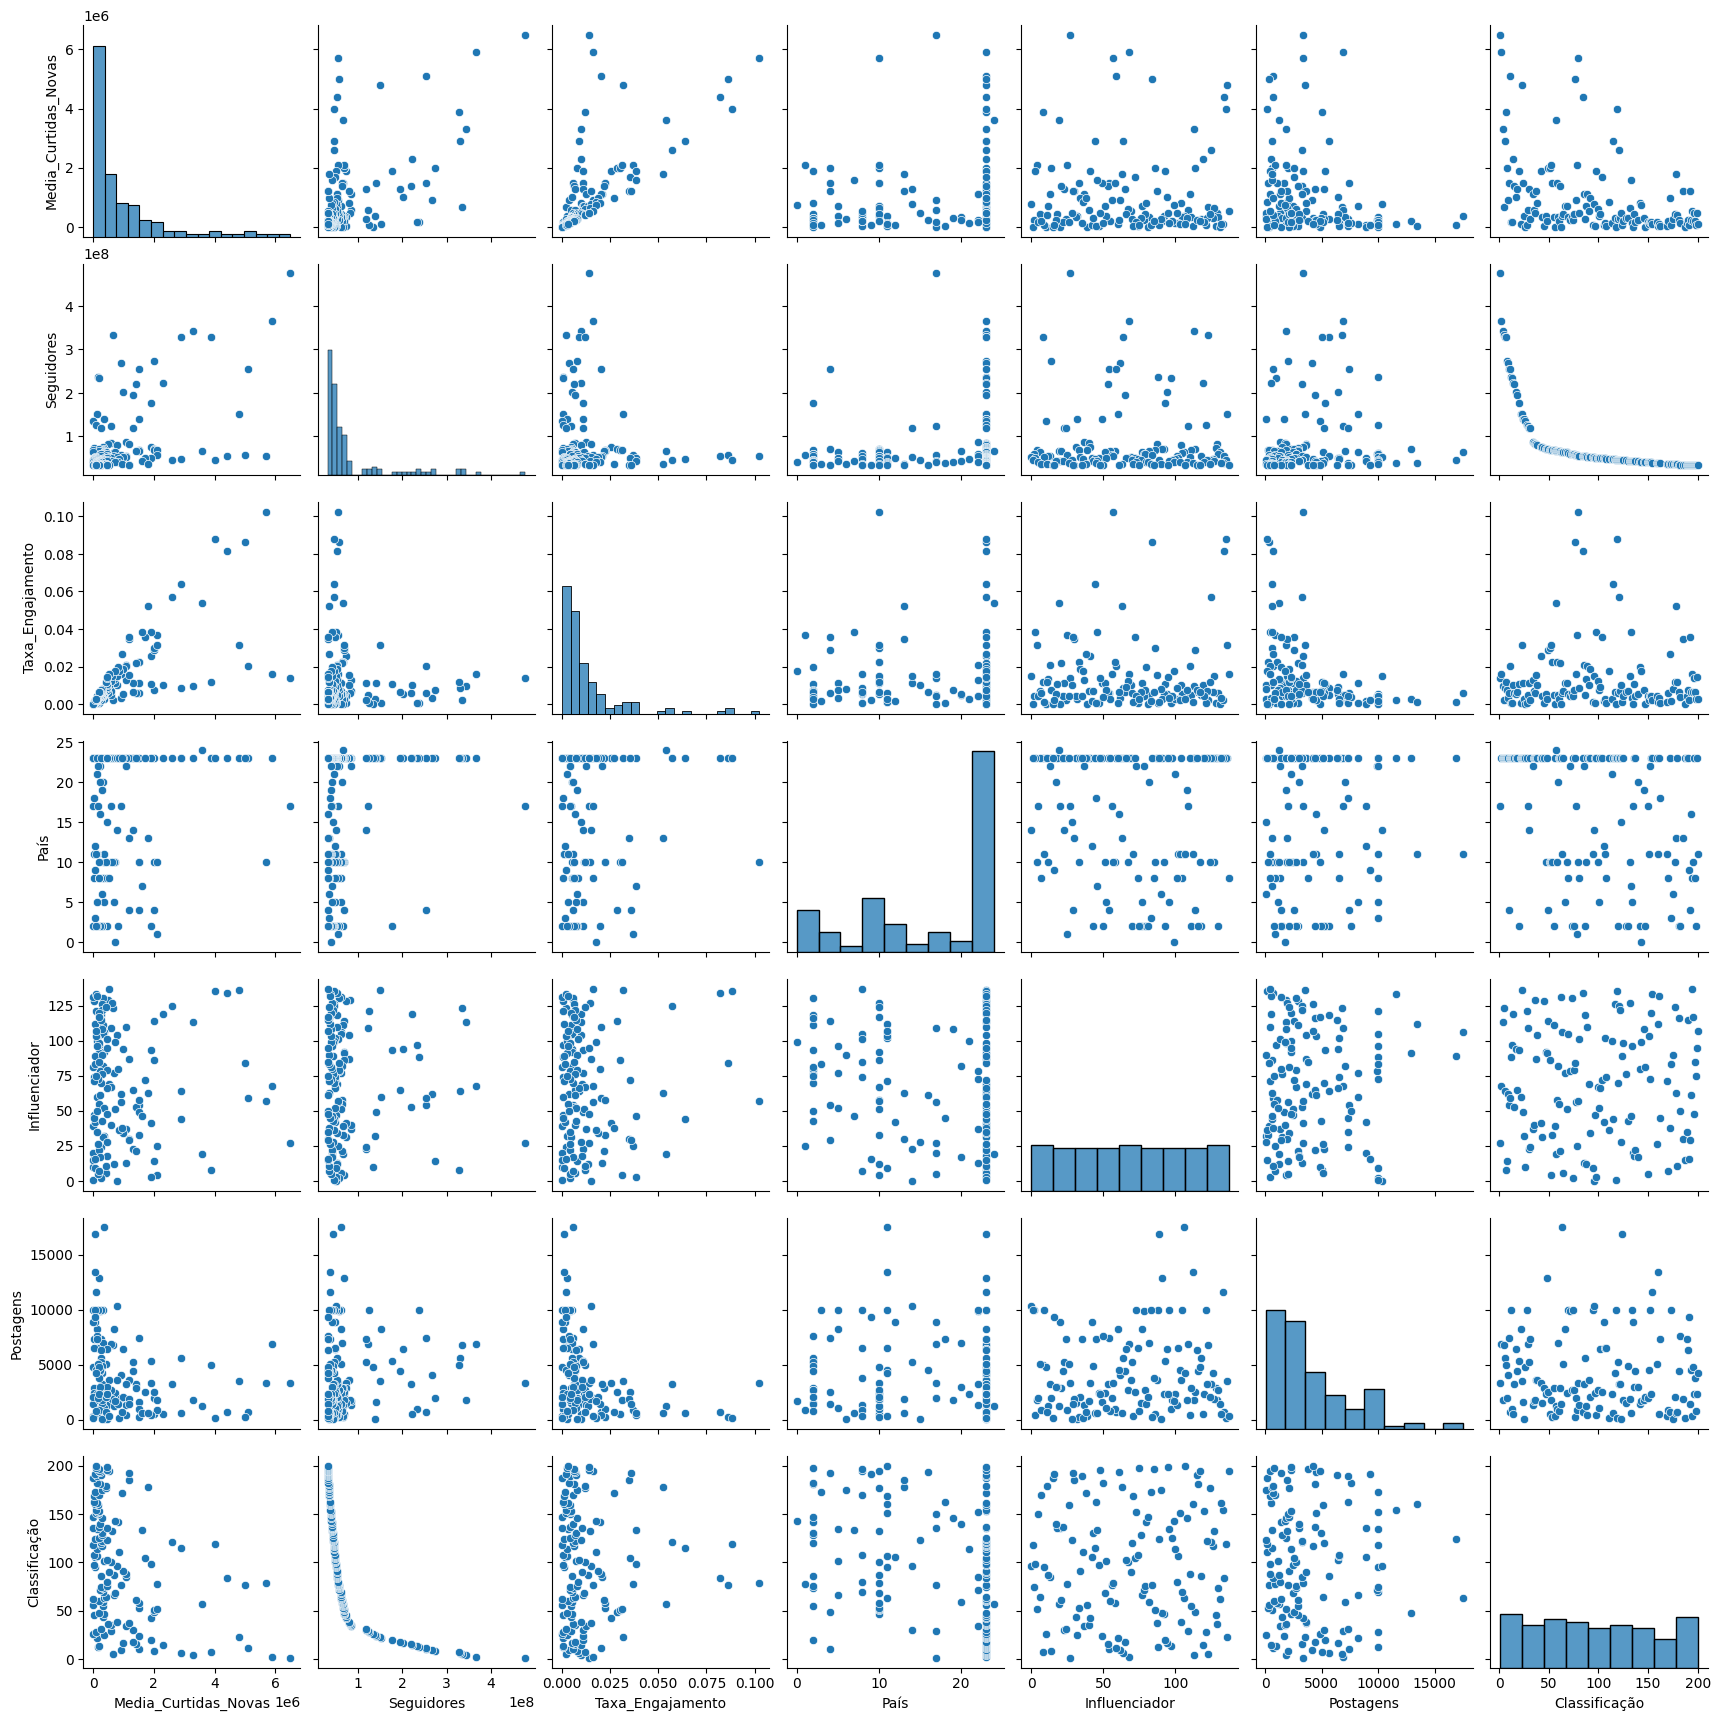

In [ ]:
# Verifique a distribuição das variáveis
sns.pairplot(df_insta[['Media_Curtidas_Novas', 'Seguidores', 'Taxa_Engajamento', 'País', 'Influenciador', 'Postagens', 'Classificação']])
plt.show()

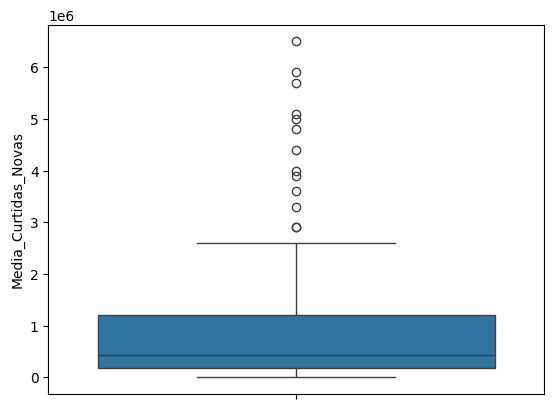

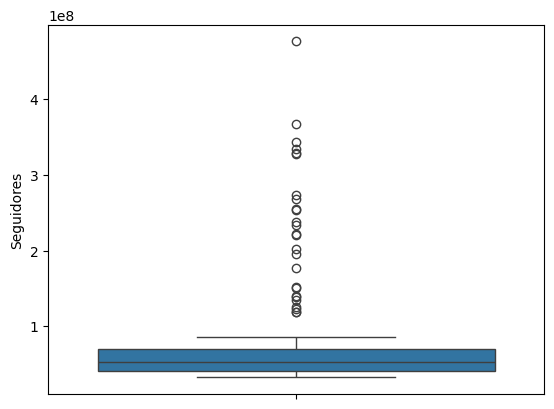

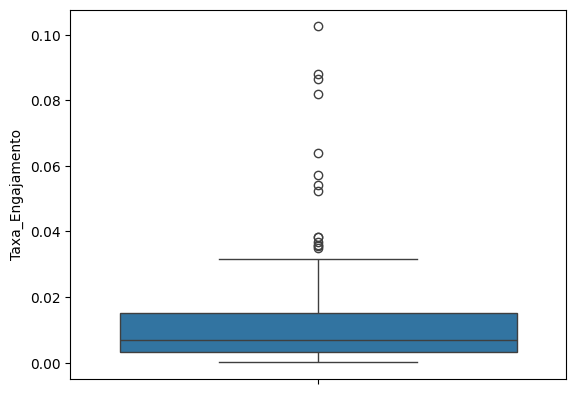

In [ ]:
# Verifique se há outliers nas variáveis
sns.boxplot(df_insta['Media_Curtidas_Novas'])
plt.show()

sns.boxplot(df_insta['Seguidores'])
plt.show()

sns.boxplot(df_insta['Taxa_Engajamento'])
plt.show()

# Separando os dados em treino e teste 🔄

In [ ]:
# Dividir os dados em variáveis independentes (X) e dependente (y)
X = df_insta[['Media_Curtidas_Novas', 'Seguidores', 'Taxa_Engajamento']]  # Variáveis independentes
y = df_insta['Media_Curtidas(target)']  # Variável dependente (target)

In [ ]:
# Dividindo os dados em conjunto de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Regressão Linear 📈

In [ ]:
# Treinar o modelo de Regressão Linear
model = linear_model.LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
# Fazendo previsões com o conjunto de teste
y_pred = model.predict(X_test)

# Avaliando o modelo 📏

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
# Imprimindo os valores das métricas de avaliação
print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'RMSE: {rmse}')
print(f'R²: {r2}')



MAE: 411566.1018466269
MSE: 272122507233.2273
RMSE: 521653.62764312036
R²: 0.8751324080709025


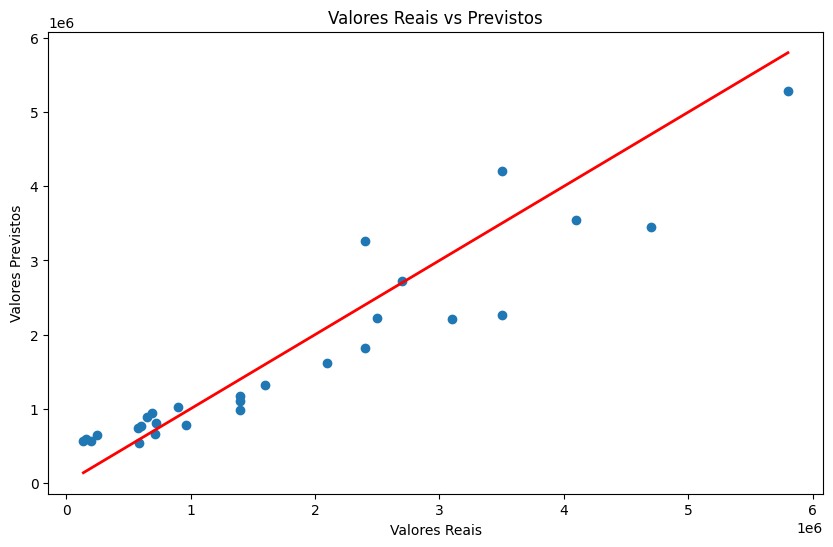

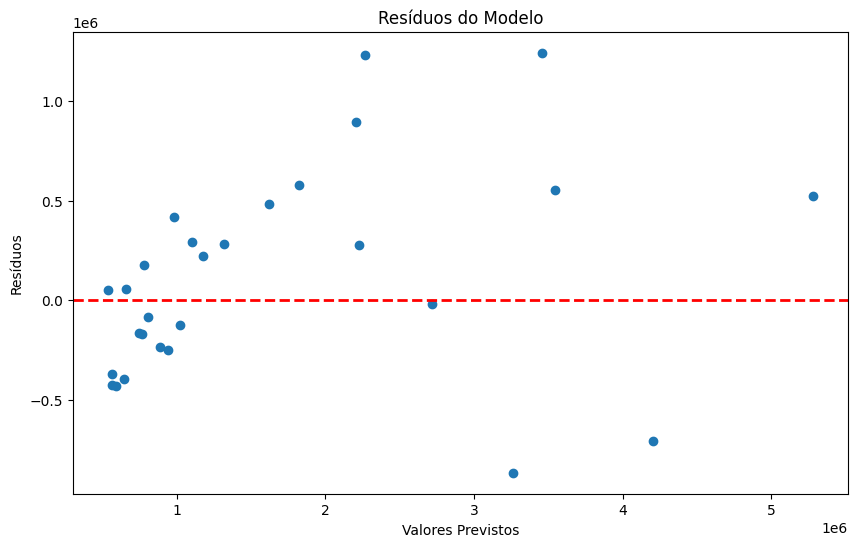

In [ ]:
# Visualização da relação entre os valores reais e previstos
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', lw=2)
plt.title('Valores Reais vs Previstos')
plt.xlabel('Valores Reais')
plt.ylabel('Valores Previstos')
plt.show()

# Visualização dos resíduos
residuos = y_test - y_pred
plt.figure(figsize=(10,6))
plt.scatter(y_pred, residuos)
plt.axhline(y=0, color='red', linestyle='--', lw=2)
plt.title('Resíduos do Modelo')
plt.xlabel('Valores Previstos')
plt.ylabel('Resíduos')
plt.show()



# Teste autocorrelação do resíduos

O Teste de Durbin-Watson é uma ferramenta importante para verificar se seus dados apresentam autocorrelação. Ao identificar a autocorrelação, pode escolher modelos estatísticos mais adequados e fazer previsões mais precisas.

In [ ]:
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
model = sm.OLS(y_train, sm.add_constant(X_train)).fit()
dw_test = durbin_watson(model.resid)
print('Durbin-Watson:', dw_test)

Durbin-Watson: 1.9895854792507388


**Resultado:**

Um valor de Durbin-Watson de 2.156 está muito próximo de 2, o que é uma boa indicação. Esse resultado sugere que não há evidência significativa de autocorrelação nos resíduos do seu modelo de regressão linear.
Interpretação do Resultado:

-> Valor próximo de 2: Indica que os resíduos são independentes, ou seja, não há correlação entre eles. Este é um resultado desejável em um modelo de regressão, pois confirma que a suposição de independência dos erros foi atendida.

# Regularização dos dados 🔃

Ridge é ideal quando você deseja manter todas as variáveis ​​no modelo, mas controlar os efeitos da multicolinearidade.

In [ ]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.datasets import make_regression

# Dados de exemplo
X, y = make_regression(n_samples=100, n_features=10, noise=0.1, random_state=42)

# Dividir em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modelo Ridge

ridge_model = Ridge(alpha=0.01) # alpha ajustado com validação cruzada
ridge_model.fit(X_train, y_train)
ridge_predictions = ridge_model.predict(X_test)
ridge_mse = mean_squared_error(y_test, ridge_predictions)
print("Ridge MSE:", ridge_mse)

ridge_model.fit(X_train, y_train)
ridge_predictions = ridge_model.predict(X_test)
ridge_mse = mean_squared_error
# Modelo Lasso
lasso_model = Lasso(alpha=0.1)  # alpha é o parâmetro lambda
lasso_model.fit(X_train, y_train)
lasso_predictions = lasso_model.predict(X_test)
lasso_mse = mean_squared_error(y_test, lasso_predictions)

print("Lasso MSE:", lasso_mse)

Ridge MSE: 0.012908434922886586
Lasso MSE: 0.18237823772606268


**Resultado:**

Ridge MSE: 0.0129: Este é um valor bastante baixo, sugerindo que o modelo de Ridge conseguiu ajustar bem os dados e apresenta um erro médio quadrático pequeno. Isso indica que o modelo tem uma boa capacidade de previsão e está capturando bem as variáveis explicativas em relação à variável dependente.

Lasso MSE: 0.1824: Este valor é significativamente mais alto do que o de Ridge, sugerindo que o modelo Lasso pode não ter se ajustado tão bem aos dados quanto o Ridge. Isso pode indicar que o Lasso eliminou algumas variáveis que, de fato, poderiam ser importantes para o modelo, pois sua característica de regularização tende a zerar coeficientes de variáveis menos relevantes, simplificando o modelo.

# Ajuste com Validação Cruzada 🔀
Essa abordagem permite um ajuste fino para melhorar o desempenho e evitar overfitting de maneira eficaz.





In [ ]:
from sklearn.model_selection import GridSearchCV

# GridSearchCV para ajustar alpha
param_grid = {'alpha': [0.01, 0.1, 1, 10, 100]}
ridge_cv = GridSearchCV(Ridge(), param_grid, scoring='neg_mean_squared_error', cv=5)
ridge_cv.fit(X_train, y_train)

print("Melhor alpha para Ridge:", ridge_cv.best_params_['alpha'])

Melhor alpha para Ridge: 0.01


# Teste de Homocedasticidade com BreuschPagan 🟰

O teste de Breusch-Pagan serve para verificar se os erros de um modelo estatístico são homocedásticos ou heterocedásticos. Em outras palavras, ele verifica se a variância dos erros é constante ao longo de todos os valores da variável independente.

Interpretação dos Resultados:

Se o valor-p for menor que 0.05, há evidências de heteroscedasticidade, e pode ser necessário ajustar o modelo (por exemplo, aplicando uma transformação nos dados ou usando um modelo de regressão robusto).

Se o valor-p for maior que 0.05, os resíduos provavelmente têm variância constante, e a suposição de homoscedasticidade é atendida.

In [ ]:
from statsmodels.stats.diagnostic import het_breuschpagan
import statsmodels.api as sm

# Supondo que 'model' seja o modelo de regressão linear ajustado
residuals = model.resid
exog = model.model.exog

# Teste de Breusch-Pagan
bp_test = het_breuschpagan(residuals, exog)

# bp_test retorna uma tupla (Lagrange multiplier statistic, p-value, f-value, f p-value)
print(f'Estatística de Lagrange multiplier: {bp_test[0]}')
print(f'Valor-p: {bp_test[1]}')


Estatística de Lagrange multiplier: 10.56834225290038
Valor-p: 0.014304387167268166


**Resultado:**

A variância dos erros não parece depender das variáveis independentes, o que é um bom sinal para a validade do seu modelo de regressão.

## **## Como ajustar a taxa de aprendizado e o número de épocas para o gradiente descendente em um modelo de regressão linear**

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDRegressor

# Suponha que seu dataset seja um DataFrame chamado 'dataset'

# Selecionando as variáveis preditoras (X) e a variável alvo (y)
# Exemplo: suponha que 'X' são as colunas 'Postagens', 'Seguidores' e 'Taxa_Engajamento', e 'y' seja 'Media_Curtidas'
X = df_insta[['Postagens', 'Seguidores', 'Taxa_Engajamento']]  # Ajuste de acordo com suas variáveis
y = df_insta['Media_Curtidas(target)']  # Substitua pelo nome da sua variável alvo

# Dividindo os dados em conjuntos de treino e teste (80% treino, 20% teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
# Definindo o modelo de regressão linear com gradiente descendente
#sgd_reg = SGDRegressor(max_iter=1000, tol=1e-3, eta0=0.01)  # max_iter é o número de épocas e eta0 é a taxa de aprendizado


In [ ]:
# Definindo o modelo de regressão linear com gradiente descendente
sgd_reg = SGDRegressor(max_iter=1000, tol=1e-3, eta0=0.001)  # Ajuste da taxa de aprendizado


In [ ]:
# Treinando o modelo
sgd_reg.fit(X_train, y_train)



SGDRegressor(eta0=0.001)

In [ ]:
# Exibindo os parâmetros otimizados (coeficiente e intercepto)
print("Coeficiente:", sgd_reg.coef_)
print("Intercepto:", sgd_reg.intercept_)

Coeficiente: [ 4.24892440e+13  3.70699686e+15 -2.50739890e+08]
Intercepto: [3.21787242e+09]


In [ ]:
# Prevendo os valores de 'y' para o conjunto de teste
y_pred = sgd_reg.predict(X_test)

# Avaliando o modelo com métricas como o R² ou erro quadrático médio (MSE)
from sklearn.metrics import mean_squared_error, r2_score

# Calculando o erro quadrático médio (MSE)
mse = mean_squared_error(y_test, y_pred)
print(f"Erro Quadrático Médio (MSE): {mse}")

# Calculando o R² (coeficiente de determinação)
r2 = r2_score(y_test, y_pred)
print(f"R²: {r2}")


Erro Quadrático Médio (MSE): 1.4825043331438887e+47
R²: -6.8026988280492465e+34


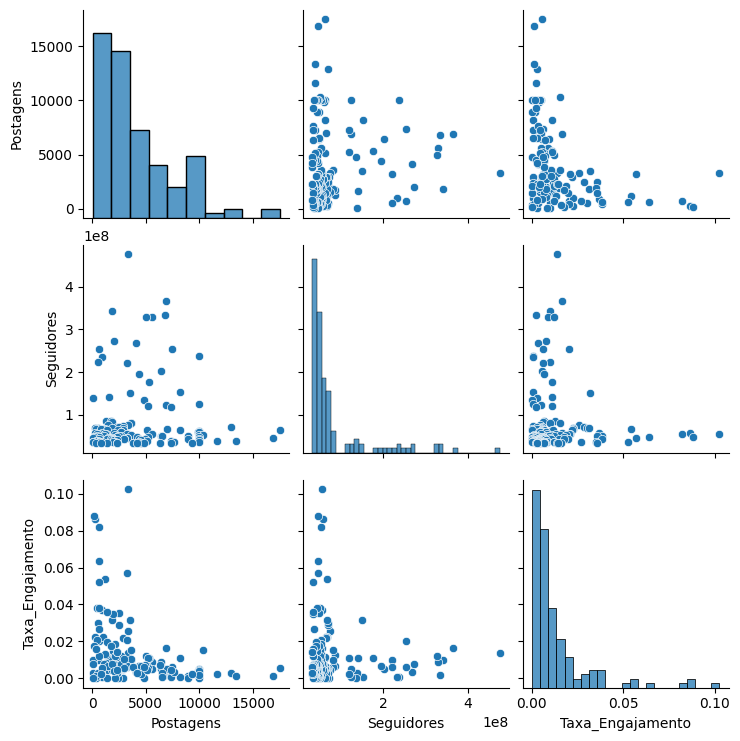

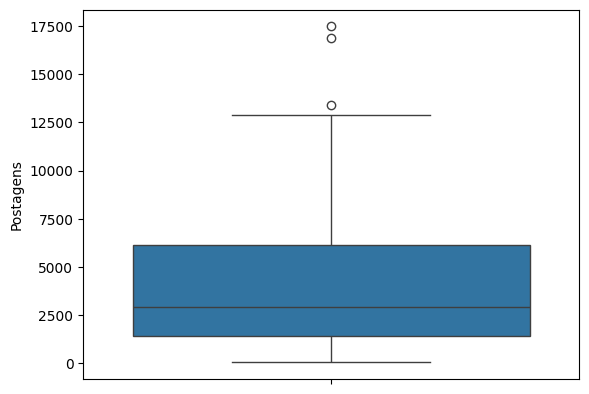

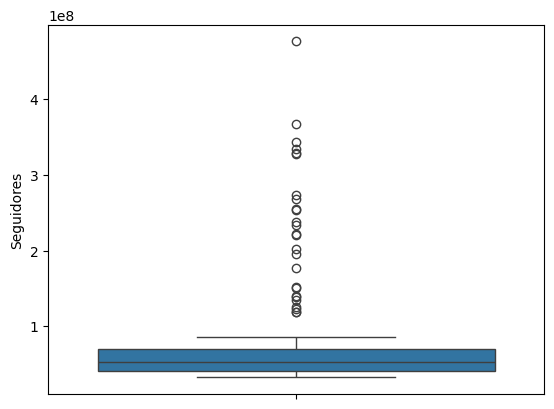

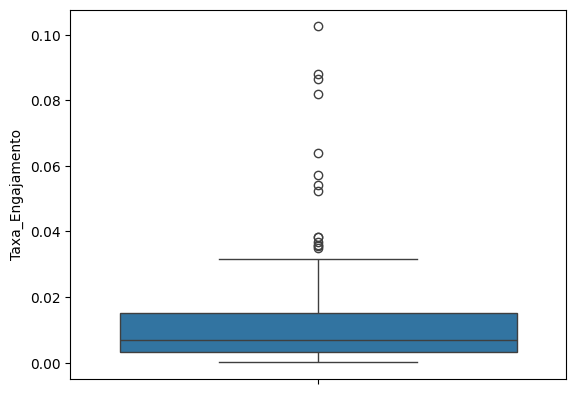

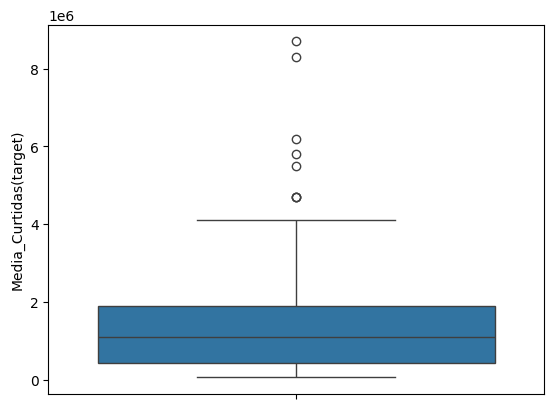

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Verifique a distribuição das variáveis
sns.pairplot(df_insta[['Postagens', 'Seguidores', 'Taxa_Engajamento']])
plt.show()

# Verifique se há outliers nas variáveis
sns.boxplot(df_insta['Postagens'])
plt.show()

sns.boxplot(df_insta['Seguidores'])
plt.show()

sns.boxplot(df_insta['Taxa_Engajamento'])
plt.show()

sns.boxplot(df_insta['Media_Curtidas(target)'])
plt.show()

#Se os gráficos mostrarem que há outliers , considere removê-los ou aplicar transformações adequadas.


In [ ]:
from sklearn.linear_model import SGDRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# Seleção das variáveis X e y
X = df_insta[['Postagens', 'Seguidores', 'Taxa_Engajamento']]
y = df_insta['Media_Curtidas(target)']

# Divisão dos dados em treino e teste (80% treino, 20% teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalização dos dados
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Definindo o modelo com uma taxa de aprendizado menor
sgd_reg = SGDRegressor(max_iter=1000, tol=1e-3, eta0=1e-5)  # Eta muito mais baixo

# Treinando o modelo
sgd_reg.fit(X_train_scaled, y_train)

# Prevendo os valores de y para o conjunto de teste
y_pred = sgd_reg.predict(X_test_scaled)

# Avaliando o modelo
mse = mean_squared_error(y_test, y_pred)
print(f"Erro Quadrático Médio (MSE): {mse}")

r2 = r2_score(y_test, y_pred)
print(f"R²: {r2}")


Erro Quadrático Médio (MSE): 4691035100632.819
R²: -1.1525535047670905


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1616: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
